<a href="https://colab.research.google.com/github/MartaPCastillo/Tesis/blob/main/Grupo%20M%C3%A9xico.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [93]:
!pip install pmdarima

In [94]:
import pandas as pd
import yfinance as yf # Para descargar datos de acciones
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.seasonal import STL
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_pacf
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
import math
from pmdarima.arima import auto_arima
from sklearn.metrics import mean_absolute_error

#Grupo México

In [95]:
#Obtener datos
df = yf.download('GMEXICOB.MX', start='2024-01-01')

/tmp/ipykernel_3119/2329736698.py:2: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('GMEXICOB.MX', start='2024-01-01')
[*********************100%***********************]  1 of 1 completed


In [96]:
print(type(df['Close']))

<class 'pandas.core.frame.DataFrame'>


In [97]:
# Eliminar nivel del ticker
df.columns = df.columns.droplevel(1)

#Análisis de la serie

##Medias Móviles

###Media Móvil Simple

In [98]:
#Calcular Media Móvil Simple de 200 días
df['SMA200'] = df['Close'].rolling(window=200).mean()

<Axes: xlabel='Date'>

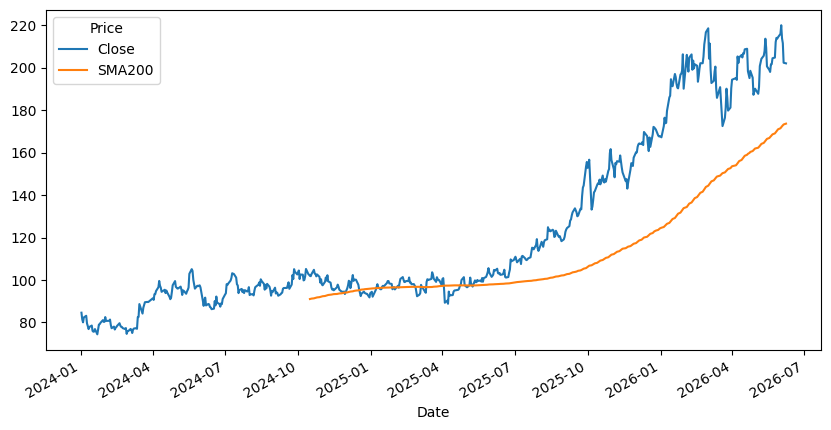

In [99]:
#Visualizar
df[['Close', 'SMA200']].plot(figsize=(10,5))

###Media Móvil Exponencial

In [100]:
#Calcular Media Móvil Exponencial de 200 días
df['EMA200'] = df['Close'].ewm(span=200, adjust=False).mean()

In [101]:
#Calcular Media Móvil Exponencial de 20 días
df['EMA20'] = df['Close'].ewm(span=20, adjust=False).mean()

<Axes: xlabel='Date'>

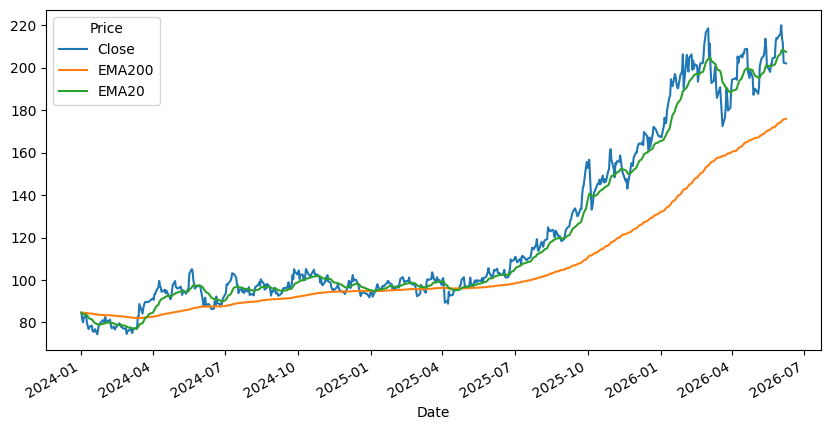

In [102]:
#Visualizar
df[['Close', 'EMA200', 'EMA20']].plot(figsize=(10,5))

##Descomposición Serie Temporal

###Modelo Aditivo

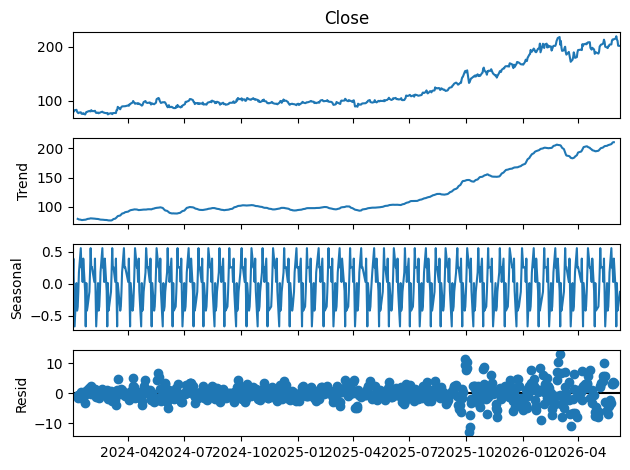

In [103]:
# Descomponer
result = seasonal_decompose(df['Close'], model='additive', period=12) # 12 meses en un año
result.plot()
plt.show()

###Modelo Multiplicativo

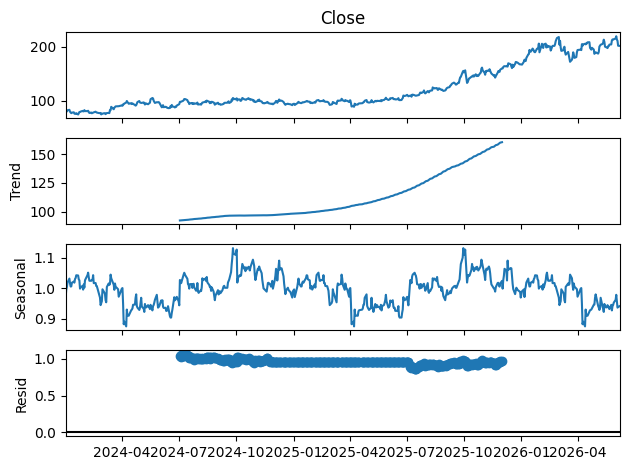

In [104]:
# Descomponer
result = seasonal_decompose(df['Close'], model='multiplicative', period=252) # 252 días hábiles en un año
result.plot()
plt.show()

In [105]:
# Seleccionar la columna de cierre y eliminar valores nulos
series = df['Close'].dropna()

In [106]:
# 2. Configurar y ejecutar la descomposición STL
# period: longitud de la estacionalidad. Para datos diarios, usualmente 365.
# robust=True ayuda a reducir la influencia de valores atípicos.
stl = STL(series, period=365, robust=True)
result = stl.fit()

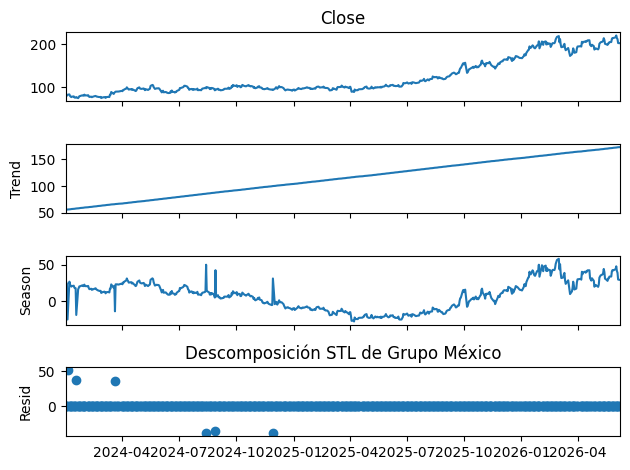

In [107]:
# 3. Visualizar los componentes
result.plot()
plt.title(f"Descomposición STL de Grupo México")
plt.tight_layout()
plt.show()

#Volatilidad

##Desviación Estándar

In [108]:
#Obtener datos
precios = df['Close']

In [109]:
# Método financiero estándar para rendimientos logarítmicos
df['Rendimientos_Log'] = np.log(precios / precios.shift(1))
print(df['Rendimientos_Log'])

Date
2024-01-02         NaN
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
                ...   
2026-06-02    0.018682
2026-06-03   -0.028553
2026-06-04   -0.010631
2026-06-05   -0.044484
2026-06-08   -0.001435
Name: Rendimientos_Log, Length: 608, dtype: float64


In [110]:
#Eliminar NaN solo de rendimientos
df.dropna(subset=['Rendimientos_Log'], inplace=True)
print(df['Rendimientos_Log'])

Date
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-06-02    0.018682
2026-06-03   -0.028553
2026-06-04   -0.010631
2026-06-05   -0.044484
2026-06-08   -0.001435
Name: Rendimientos_Log, Length: 607, dtype: float64


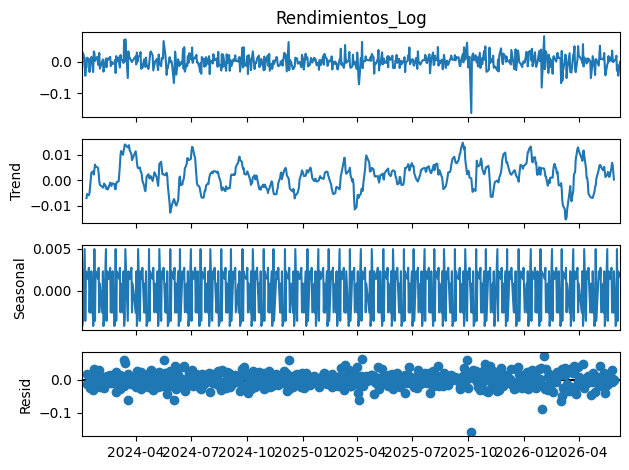

In [111]:
# Descomponer
result = seasonal_decompose(df['Rendimientos_Log'], model='additive', period=12) # 12 meses en un año
result.plot()
plt.show()

In [112]:
# 2. Configurar y ejecutar la descomposición STL
# period: longitud de la estacionalidad. Para datos diarios, usualmente 365.
# robust=True ayuda a reducir la influencia de valores atípicos.
stl = STL(df['Rendimientos_Log'], period=365, robust=True)
result = stl.fit()

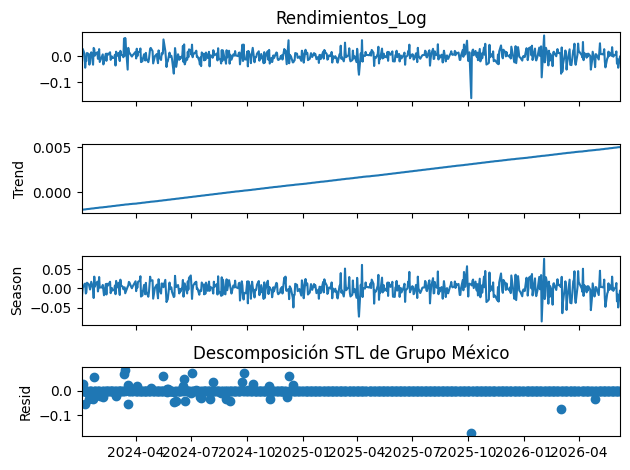

In [113]:
# 3. Visualizar los componentes
result.plot()
plt.title(f"Descomposición STL de Grupo México")
plt.tight_layout()
plt.show()

In [114]:
#Calcular la desviación estándar de los rendimientos (Volatilidad Diaria)
volatilidad_diaria = df['Rendimientos_Log'].std()

In [115]:
#Anualizar la volatilidad (multiplicando por la raíz cuadrada de 252 días hábiles al año)
volatilidad_anual = volatilidad_diaria * np.sqrt(252)

In [116]:
Volatilidad_diaria_porcentaje = volatilidad_diaria * 100
Volatilidad_anual_porcentaje = volatilidad_anual * 100

In [117]:
print(f"Volatilidad diaria: {volatilidad_diaria:.4f} = {Volatilidad_diaria_porcentaje:.4f} %")
print(f"Volatilidad anualizada: {volatilidad_anual:.4f} = {Volatilidad_anual_porcentaje:.4f} %")

Volatilidad diaria: 0.0223 = 2.2271 %
Volatilidad anualizada: 0.3535 = 35.3534 %


##Average True Range

In [118]:
#Calcular los 3 componentes del True Range (TR)
high_low = df['High'] - df['Low']
high_close = np.abs(df['High'] - df['Close'].shift(1))
low_close = np.abs(df['Low'] - df['Close'].shift(1))

In [119]:
print(high_low)

Date
2024-01-03    3.811026
2024-01-04    2.643276
2024-01-05    6.381882
2024-01-08    2.570862
2024-01-09    4.200277
                ...   
2026-06-02    7.729996
2026-06-03    6.209991
2026-06-04    7.380005
2026-06-05    8.479996
2026-06-08    4.629990
Length: 607, dtype: float64


In [120]:
print(high_close)

Date
2024-01-03         NaN
2024-01-04    0.117690
2024-01-05    6.046940
2024-01-08    0.887111
2024-01-09    0.253491
                ...   
2026-06-02    8.000000
2026-06-03    0.279999
2026-06-04    0.610001
2026-06-05    3.300003
2026-06-08    3.539993
Length: 607, dtype: float64


In [121]:
print(low_close)

Date
2024-01-03          NaN
2024-01-04     2.525587
2024-01-05     0.334942
2024-01-08     1.683751
2024-01-09     3.946785
                ...    
2026-06-02     0.270004
2026-06-03     6.489990
2026-06-04     6.770004
2026-06-05    11.779999
2026-06-08     1.089996
Length: 607, dtype: float64


In [122]:
#Unir y obtener el máximo de los 3 para cada día
ranges = pd.concat([high_low, high_close, low_close], axis=1)
true_range = ranges.max(axis=1)

In [123]:
print(true_range)

Date
2024-01-03     3.811026
2024-01-04     2.643276
2024-01-05     6.381882
2024-01-08     2.570862
2024-01-09     4.200277
                ...    
2026-06-02     8.000000
2026-06-03     6.489990
2026-06-04     7.380005
2026-06-05    11.779999
2026-06-08     4.629990
Length: 607, dtype: float64


In [124]:
#Calcular el ATR (suavizado clásico de Wilder, n=14)
atr_period = 14
atr = true_range.copy()

In [125]:
#El primer ATR es la media simple de los primeros 14 días
atr.iloc[atr_period-1] = true_range.iloc[:atr_period].mean()

In [126]:
#Iterar para aplicar la fórmula suavizada
for i in range(atr_period, len(true_range)):
    atr.iloc[i] = (atr.iloc[i-1] * (atr_period - 1) + true_range.iloc[i]) / atr_period

df['ATR_Calculado'] = atr
print(df[['High', 'Low', 'Close', 'ATR_Calculado']].tail())

Price             High         Low       Close  ATR_Calculado
Date                                                         
2026-06-02  223.830002  216.100006  219.899994       7.607837
2026-06-03  219.619995  213.410004  213.710007       7.527991
2026-06-04  214.320007  206.940002  211.449997       7.517421
2026-06-05  208.149994  199.669998  202.250000       7.821890
2026-06-08  205.789993  201.160004  201.960007       7.593897


In [127]:
#ATR diario
atr_diario = atr.mean()
print(f"ATR diario: {atr_diario:.4f}")

ATR diario: 4.2173


In [128]:
#ATR Anualizado
atr_anualizado = atr.mean() * np.sqrt(252)
print(f"ATR anualizado: {atr_anualizado:.4f}")

ATR anualizado: 66.9472


#Parámetros (p,d,q)

##Precios Diferenciados

###Serie Estacionaria


In [138]:
#Obtener datos
precios = df['Close']

In [139]:
# Función para realizar la prueba de Dickey-Fuller Aumentada
def probar_estacionariedad(serie, titulo):
    print(f"\n--- Prueba ADF para: {titulo} ---")
    resultado = adfuller(serie.dropna())
    estadistico = resultado[0]
    valor_p = resultado[1]
    criticos = resultado[4]

    print(f"Estadístico de Dickey-Fuller: {estadistico:.4f}")
    print(f"Valor p: {valor_p:.4f}")

    if valor_p < 0.05:
        print("Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).")
    else:
        print("Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).")

    return valor_p

In [140]:
# Ejecutar prueba en Precios (Original)
probar_estacionariedad(precios, "Precios de Cierre (Original)")


--- Prueba ADF para: Precios de Cierre (Original) ---
Estadístico de Dickey-Fuller: -0.0215
Valor p: 0.9567
Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).


np.float64(0.9567205278261871)

####Diferenciando

In [141]:
# Calcular la primera diferencia del precio de cierre (columna 'Close')
differenced_prices = precios.diff().dropna()

In [142]:
# Mostrar los primeros elementos de la serie diferenciada
print(differenced_prices.head())

Date
2024-01-04   -1.412155
2024-01-05    2.308334
2024-01-08    0.778481
2024-01-09   -3.611847
2024-01-10   -1.213036
Name: Close, dtype: float64


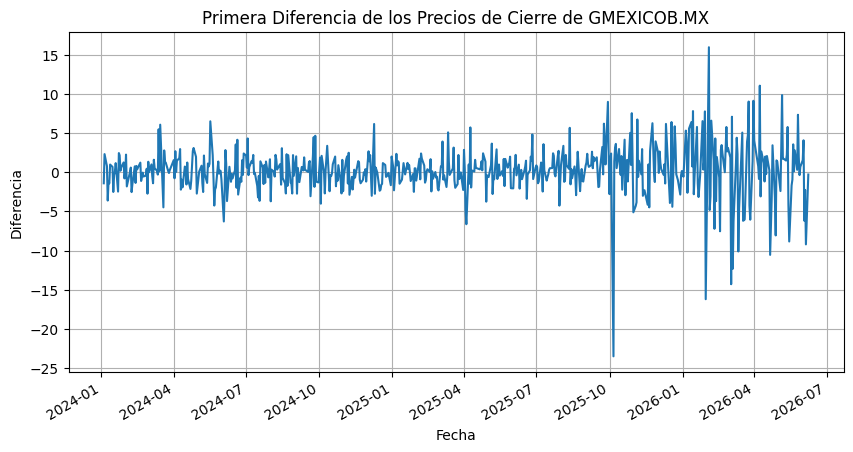

In [143]:
# Visualizar la serie diferenciada
plt.figure(figsize=(10,5))
differenced_prices.plot()
plt.title(f'Primera Diferencia de los Precios de Cierre de {"GMEXICOB.MX"}')
plt.xlabel('Fecha')
plt.ylabel('Diferencia')
plt.grid(True)
plt.show()

In [144]:
# Ejecutar prueba en serie diferenciada
probar_estacionariedad(differenced_prices, "Serie diferenciada")


--- Prueba ADF para: Serie diferenciada ---
Estadístico de Dickey-Fuller: -26.9775
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

###Función de Autocorrelación

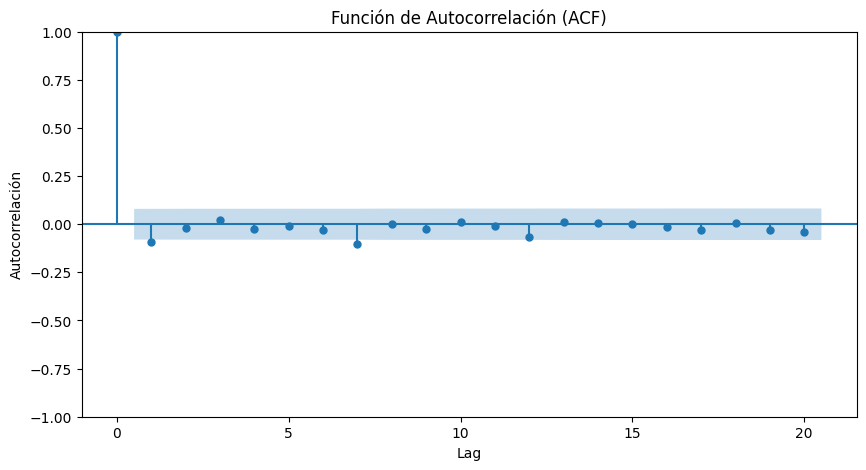

In [145]:
#Graficar la ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(differenced_prices, lags=20, ax=ax) # Plot first 20 lags
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelación")
ax.set_title("Función de Autocorrelación (ACF)")
plt.show()

###Función de Autocorrelación Parcial (PACF)

<Figure size 1000x500 with 0 Axes>

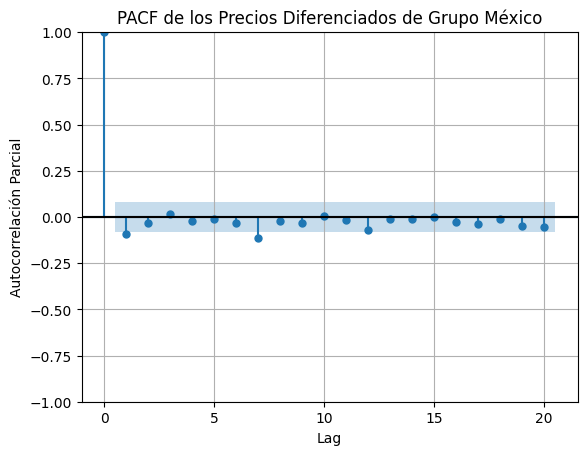

In [146]:
#Graficar la PACF
plt.figure(figsize=(10, 5))
plot_pacf(differenced_prices, lags=20, method='ywm') # method='ywm' es Yule-Walker modificado
plt.title('PACF de los Precios Diferenciados de Grupo México')
plt.xlabel('Lag')
plt.ylabel('Autocorrelación Parcial')
plt.axhline(y=0, color='k', linestyle='-')
plt.grid(True)
plt.show()

##Rendimientos Logarítmicos

In [147]:
#Cargar datos y calcular rendimientos logarítmicos
df['log_Close'] = np.log(df['Close'])

In [148]:
print(df['log_Close'])

Date
2024-01-03    4.400357
2024-01-04    4.382874
2024-01-05    4.411296
2024-01-08    4.420702
2024-01-09    4.376295
                ...   
2026-06-02    5.393173
2026-06-03    5.364620
2026-06-04    5.353989
2026-06-05    5.309505
2026-06-08    5.308070
Name: log_Close, Length: 607, dtype: float64


In [149]:
#Prueba de estacionariedad (Dickey-Fuller Aumentada)
probar_estacionariedad(df['log_Close'], "Retornos Logarítmicos")


--- Prueba ADF para: Retornos Logarítmicos ---
Estadístico de Dickey-Fuller: -0.2604
Valor p: 0.9309
Resultado: **La serie NO es ESTACIONARIA** (p >= 0.05, no se rechaza H0).


np.float64(0.9309332821704387)

###Estacionariedad

In [150]:
df['rendimiento_log'] = df['log_Close'].diff().dropna()

In [151]:
print(df['rendimiento_log'])

Date
2024-01-03         NaN
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-06-02    0.018682
2026-06-03   -0.028553
2026-06-04   -0.010631
2026-06-05   -0.044484
2026-06-08   -0.001435
Name: rendimiento_log, Length: 607, dtype: float64


In [152]:
#Prueba de estacionariedad (Dickey-Fuller Aumentada)
probar_estacionariedad(df['rendimiento_log'], "Retornos Logarítmicos Diferenciados")


--- Prueba ADF para: Retornos Logarítmicos Diferenciados ---
Estadístico de Dickey-Fuller: -26.8405
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

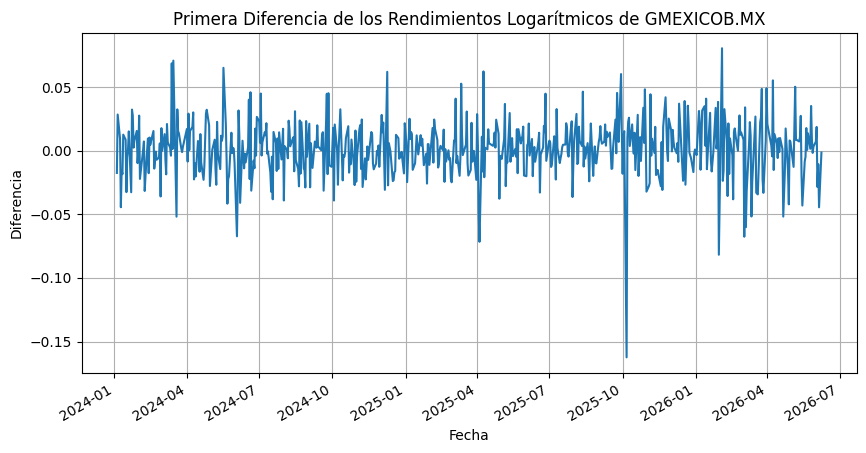

In [153]:
# Visualizar la serie diferenciada
plt.figure(figsize=(10,5))
df['rendimiento_log'].plot()
plt.title(f'Primera Diferencia de los Rendimientos Logarítmicos de {"GMEXICOB.MX"}')
plt.xlabel('Fecha')
plt.ylabel('Diferencia')
plt.grid(True)
plt.show()

###Función de Autocorrelación

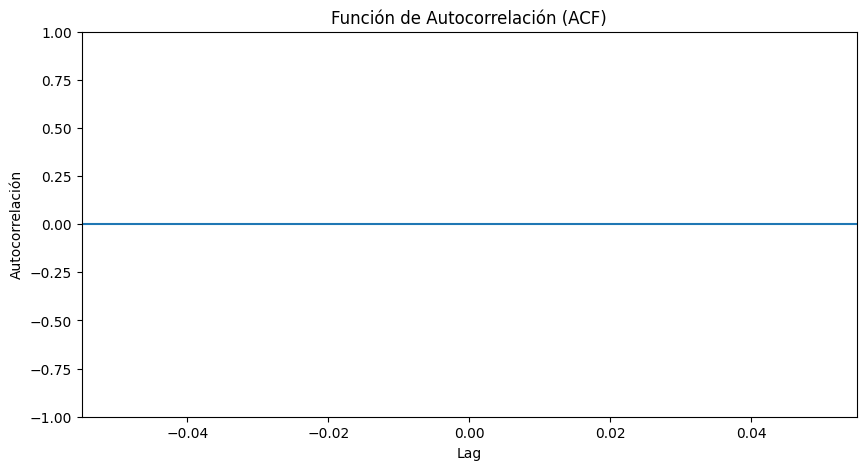

In [154]:
#Gráfica ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(df['rendimiento_log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Autocorrelación")
ax.set_title("Función de Autocorrelación (ACF)")
plt.show()

###Función de Autocorrelación Parcial

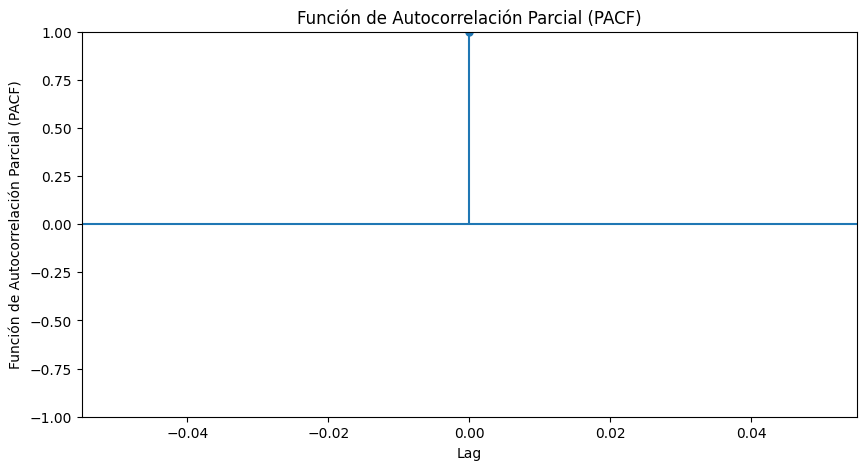

In [155]:
#Gráfica PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(df['rendimiento_log'], lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_ylabel("Función de Autocorrelación Parcial (PACF)")
ax.set_title("Función de Autocorrelación Parcial (PACF)")
plt.show()

#ARIMA

In [156]:
# Fit the ARIMA model
# Initial ARIMA Model parameters
p, d, q = 0,1,0
model = ARIMA(df['rendimiento_log'], order=(p, d, q))
model_fit = model.fit()
model_summary = model_fit.summary()
model_summary

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:        rendimiento_log   No. Observations:                  607
Model:                 ARIMA(0, 1, 0)   Log Likelihood                1201.427
Date:                Tue, 09 Jun 2026   AIC                          -2400.854
Time:                        01:29:11   BIC                          -2396.447
Sample:                             0   HQIC                         -2399.139
                                - 607                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
sigma2         0.0011   3.66e-05     29.377      0.000       0.001       0.001
===================================================================================
Ljung-Box (L1) (Q):                 175.01   Jarque-Bera (JB):               348.59
Prob(Q):                              0.00   Prob(JB):                         0.00
Heteroskedasticity (H):               1.47   Skew:                            -0.03
Prob(H) (two-sided):                  0.01   Kurtosis:                         6.72
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

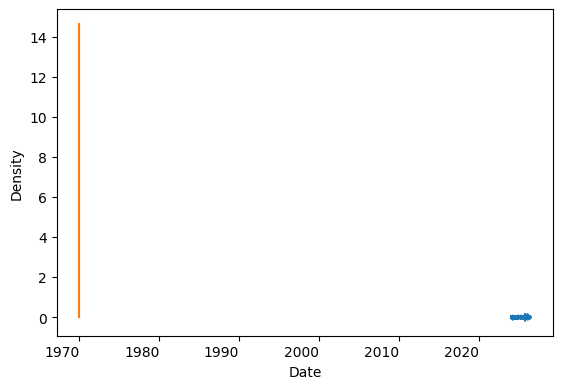

In [157]:
# plot residual errors
residuals = model_fit.resid
residuals.plot()
residuals.plot(kind='kde')
plt.show()

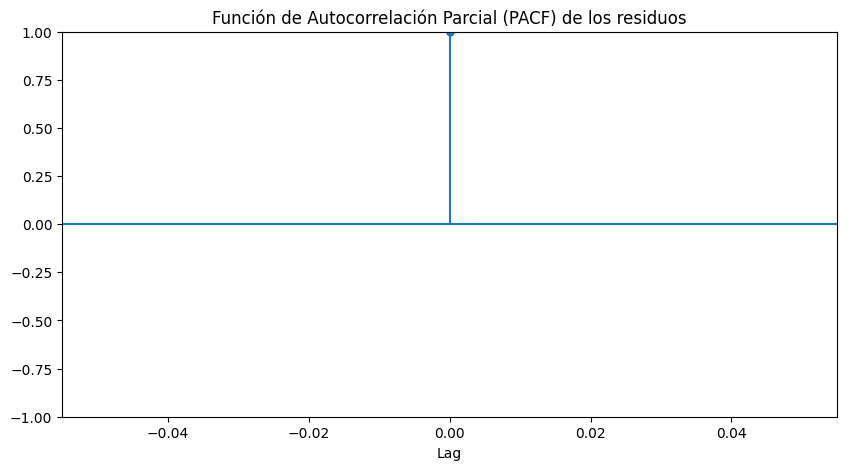

In [158]:
#Gráfica PACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_pacf(residuals, lags=20, ax=ax)
ax.set_xlabel("Lag")
ax.set_title("Función de Autocorrelación Parcial (PACF) de los residuos")
plt.show()

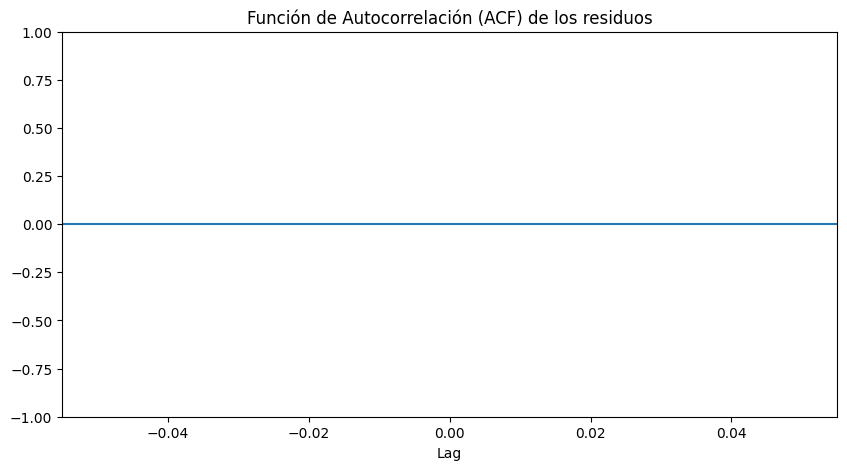

In [159]:
#Graficar la ACF
fig, ax = plt.subplots(figsize=(10, 5))
plot_acf(residuals, lags=20, ax=ax) # Plot first 20 lags
ax.set_xlabel("Lag")
ax.set_title("Función de Autocorrelación (ACF) de los residuos")
plt.show()

In [160]:
##Ejemplo básico
model = auto_arima(
    df['rendimiento_log'].dropna(),  # Serie temporal, asegurándose de que no haya NaN
    start_p=0,          # Orden AR inicial
    start_q=0,          # Orden MA inicial
    max_p=5,            # Máximo orden AR
    max_q=5,            # Máximo orden MA
    m=1,                # Periodo estacional (1 si no hay estacionalidad)
    seasonal=False,     # True si la serie es estacional
    stepwise=True,      # Usa búsqueda paso a paso para mayor velocidad
    trace=True          # Muestra el proceso de selección
)

# Resumen del modelo encontrado
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-2889.642, Time=0.04 sec
 ARIMA(1,0,0)(0,0,0)[0]             : AIC=-2891.839, Time=0.06 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-2891.904, Time=0.05 sec
 ARIMA(1,0,1)(0,0,0)[0]             : AIC=-2889.928, Time=0.07 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-2889.915, Time=0.13 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-2889.536, Time=0.34 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-2893.246, Time=0.24 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-2890.391, Time=0.14 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-2891.377, Time=0.21 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=-2891.324, Time=0.34 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-2893.114, Time=0.35 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-2889.321, Time=0.79 sec

Best model:  ARIMA(0,0,1)(0,0,0)[0] intercept
Total fit time: 2.775 seconds
                               SARIMAX Results                              

#Monte Carlo

In [161]:
#Calcular los retornos
retornos = df['Rendimientos_Log'].dropna()
print (retornos)

Date
2024-01-03   -0.037720
2024-01-04   -0.017483
2024-01-05    0.028422
2024-01-08    0.009406
2024-01-09   -0.044407
                ...   
2026-06-02    0.018682
2026-06-03   -0.028553
2026-06-04   -0.010631
2026-06-05   -0.044484
2026-06-08   -0.001435
Name: Rendimientos_Log, Length: 607, dtype: float64


In [162]:
# Ejecutar prueba en Precios Retornos
probar_estacionariedad(retornos, "Retornos")


--- Prueba ADF para: Retornos ---
Estadístico de Dickey-Fuller: -26.8365
Valor p: 0.0000
Resultado: **La serie es ESTACIONARIA** (p < 0.05, rechazamos H0).


0.0

In [163]:
#Calculamos la media
media_retornos = retornos.mean()
print(media_retornos)

0.0014332669777022378


In [164]:
#Calculamos la desviación estándar
desviacion_retornos = retornos.std()
print(desviacion_retornos)

0.022270570957056972


In [165]:
# Definir el número de simulaciones (escenarios) y el número de días a proyectar
num_simulaciones = 100 # Número de escenarios Monte Carlo
num_dias_a_proyectar = 100 # Número de días en el futuro para cada simulación

In [166]:
# Obtener el último precio de cierre del DataFrame
ultimo_precio_cierre = df['Close'].iloc[-1]
print(ultimo_precio_cierre)

201.9600067138672


In [167]:
# Lista para almacenar todos los escenarios de precios simulados
monte_carlo_simulaciones = []

In [168]:
for _ in range(num_simulaciones):
    # Para cada simulación, empezar con el último precio conocido
    current_scenario_prices = [ultimo_precio_cierre]
    for _ in range(num_dias_a_proyectar):
        # Generar números aleatorios basado
        aleatorio = np.random.normal(0, 1)
        # Calcular el siguiente precio
        dt = 1/252
        precio_siguiente = current_scenario_prices[-1] * np.exp((media_retornos - 0.5 * desviacion_retornos**2) * dt + desviacion_retornos * np.sqrt(dt) * aleatorio)
        current_scenario_prices.append(precio_siguiente)
    monte_carlo_simulaciones.append(current_scenario_prices)

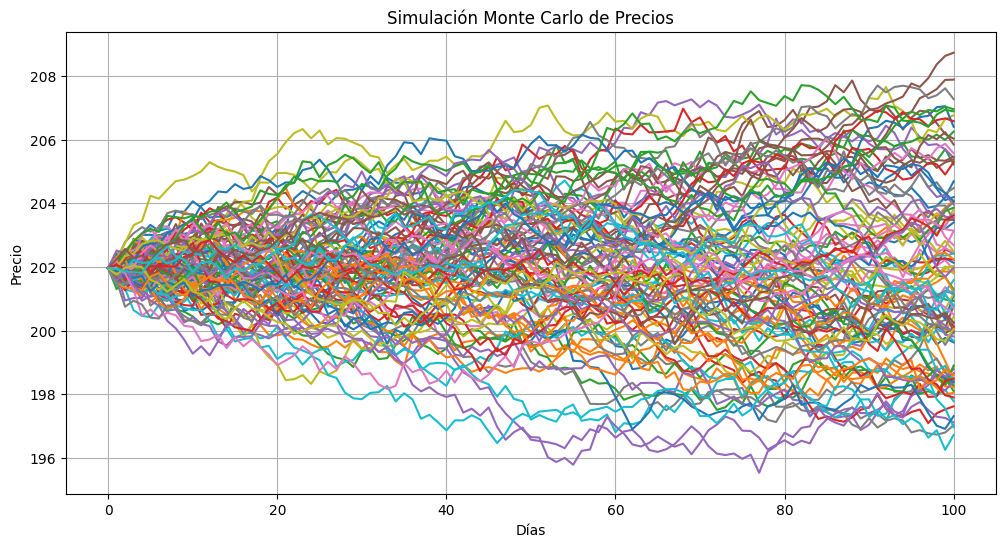

In [169]:
plt.figure(figsize=(12,6))

for simulacion in monte_carlo_simulaciones:
    plt.plot(simulacion)

plt.title('Simulación Monte Carlo de Precios')
plt.xlabel('Días')
plt.ylabel('Precio')
plt.grid(True)

plt.show()

##Predicción precio

In [170]:
# Re-creating monte_carlo_simulaciones_df as a DataFrame
# This assumes 'monte_carlo_simulaciones' is still available from previous cells
monte_carlo_simulaciones_df = pd.DataFrame(monte_carlo_simulaciones).T

In [171]:
# Now, with monte_carlo_simulaciones_df as a DataFrame, this indexing is valid
ultima_columna = monte_carlo_simulaciones_df.iloc[:,-1]
print(ultima_columna)

0      201.960007
1      201.930468
2      201.860660
3      201.828782
4      201.821533
          ...    
96     201.373851
97     201.570468
98     200.933782
99     201.212334
100    201.214639
Name: 99, Length: 101, dtype: float64


In [172]:
#Precio de cierre número 100
precio_cien = df['Close'][102]
print(precio_cien)

96.53411865234375


/tmp/ipykernel_3119/3475398454.py:2: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  precio_cien = df['Close'][102]


In [173]:
#Calcular Ganancias / Pérdidas

Ganancia_Pérdida = []
for precio in ultima_columna:
    ganancia_perdida = precio - precio_cien
    Ganancia_Pérdida.append(ganancia_perdida)

In [174]:
# Re-creating monte_carlo_simulaciones_df as a DataFrame
# This assumes 'monte_carlo_simulaciones' is still available from previous cells
Ganancia_Pérdida = pd.DataFrame(Ganancia_Pérdida).T
print(Ganancia_Pérdida)

          0           1           2           3           4           5    \
0  105.425888  105.396349  105.326542  105.294663  105.287414  105.626067   

          6           7           8           9    ...         91   \
0  105.876406  106.102601  105.799261  105.696872  ...  104.320956   

          92          93          94          95          96         97   \
0  104.731063  104.798174  104.724812  104.628414  104.839732  105.03635   

          98          99         100  
0  104.399664  104.678215  104.68052  

[1 rows x 101 columns]


In [175]:
#Contar %Ganancias y %Pérdidas si el precio de compra es de $179.56

# Ensure Ganancia_Pérdida is a DataFrame as expected for calculations.
# This step is necessary if Ganancia_Pérdida is currently a list from previous cell execution order.
if isinstance(Ganancia_Pérdida, list):
    Ganancia_Pérdida = pd.DataFrame(Ganancia_Pérdida).T

Ganancia = (Ganancia_Pérdida > 0).sum().sum()
Perdida = (Ganancia_Pérdida < 0).sum().sum()

# Obtener el número total de simulaciones
num_simulaciones = Ganancia_Pérdida.size

# Calcular porcentajes
porcentaje_ganancia = (Ganancia / num_simulaciones) * 100
porcentaje_perdida = (Perdida / num_simulaciones) * 100

print(f"Número de simulaciones con ganancia: {Ganancia} ({porcentaje_ganancia:.2f} %)")
print(f"Número de simulaciones con pérdida: {Perdida} ({porcentaje_perdida:.2f} %)")
print(f"Número total de simulaciones: {num_simulaciones}")

Número de simulaciones con ganancia: 101 (100.00 %)
Número de simulaciones con pérdida: 0 (0.00 %)
Número total de simulaciones: 101


In [176]:
#Ganancia potencial
Ganancia_potencial = Ganancia_Pérdida.mean(axis=1).iloc[0]
print(Ganancia_potencial)

105.90356762410165


In [177]:
#Precio Potencial
Precio_potencial = precio_cien + Ganancia_potencial
print(Precio_potencial)

202.4376862764454


##Error Cuadrático Medio (RMSE)


In [178]:
monte_carlo_simulaciones_df = pd.DataFrame(monte_carlo_simulaciones).T

In [179]:
prediccion_mc = monte_carlo_simulaciones_df.mean(axis=1)

In [183]:
ultimos_101 = precios.iloc[-103:-2]
print(ultimos_101)

Date
2026-01-07    173.756958
2026-01-08    173.993454
2026-01-09    179.561325
2026-01-12    185.956985
2026-01-13    186.696091
                 ...    
2026-05-29    214.289993
2026-06-01    215.830002
2026-06-02    219.899994
2026-06-03    213.710007
2026-06-04    211.449997
Name: Close, Length: 101, dtype: float64


In [184]:
print(len(ultimos_101))
print(len(prediccion_mc))

101
101


In [185]:
rmse = np.sqrt(mean_squared_error(ultimos_101, prediccion_mc[0:]))
print(f"RMSE Monte Carlo: {rmse:.4f}")

RMSE Monte Carlo: 11.1129


In [186]:
rmse_porcentaje = (rmse / ultimos_101.mean()) * 100
print(f"% RMSE Monte Carlo: {rmse_porcentaje:.4f} %")

% RMSE Monte Carlo: 5.6033 %


##Error Cuadrático Medio (MAE)

In [187]:
mae = mean_absolute_error(ultimos_101, prediccion_mc)

print(f"MAE Monte Carlo: {mae:.4f}")

MAE Monte Carlo: 8.6985
